**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 07 — Main Model Architecture: CLIP + Cross-Attention + MLP

Defines and validates the full multimodal model:
- Frozen CLIP ViT-B/32 (image + text encoder)
- Bidirectional cross-attention fusion
- MLP classification head

All classes defined inline — zero `src/` dependencies.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [13]:
# ── Model definitions ─────────────────────────────────────────

def _ensure_tensor(out):
    """Extract tensor from model output if it returns a dataclass instead of a plain tensor."""
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, "last_hidden_state"):
        return out.last_hidden_state[:, 0]
    return out[0]


class CLIPEncoder(nn.Module):
    """
    Frozen CLIP ViT-B/32 backbone.
    Returns (image_embeds, text_embeds), each shape (B, 512).
    """
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        # Freeze all CLIP weights
        for param in self.clip.parameters():
            param.requires_grad_(False)

    def forward(self, pixel_values, input_ids, attention_mask):
        img_emb = _ensure_tensor(self.clip.get_image_features(
            pixel_values=pixel_values
        ))                                        # (B, 512)
        txt_emb = _ensure_tensor(self.clip.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask
        ))                                        # (B, 512)
        # L2-normalize (CLIP convention)
        img_emb = F.normalize(img_emb, dim=-1)
        txt_emb = F.normalize(txt_emb, dim=-1)
        return img_emb, txt_emb


class CrossAttentionFusion(nn.Module):
    """
    Bidirectional cross-attention between image and text embeddings.
    Each modality attends to the other, outputs are concatenated: (B, 1024).
    """
    def __init__(self, embed_dim=512, num_heads=4, dropout=0.1):
        super().__init__()
        # Image attends to text
        self.img_to_txt_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        # Text attends to image
        self.txt_to_img_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm_img = nn.LayerNorm(embed_dim)
        self.norm_txt = nn.LayerNorm(embed_dim)

    def forward(self, img_emb, txt_emb):
        # Expand to sequence dim: (B, 512) → (B, 1, 512)
        img_seq = img_emb.unsqueeze(1)
        txt_seq = txt_emb.unsqueeze(1)

        # Image attends to text
        img_ctx, img_attn = self.img_to_txt_attn(
            query=img_seq, key=txt_seq, value=txt_seq
        )                                          # (B, 1, 512)
        img_out = self.norm_img(img_emb + img_ctx.squeeze(1))  # residual

        # Text attends to image
        txt_ctx, txt_attn = self.txt_to_img_attn(
            query=txt_seq, key=img_seq, value=img_seq
        )                                          # (B, 1, 512)
        txt_out = self.norm_txt(txt_emb + txt_ctx.squeeze(1))  # residual

        # Concatenate both enriched representations
        fused = torch.cat([img_out, txt_out], dim=-1)  # (B, 1024)

        return fused, img_attn, txt_attn


class ClassificationHead(nn.Module):
    """MLP classifier: 1024 → 256 → 128 → 2"""
    def __init__(self, input_dim=1024, hidden_dims=(256, 128), num_classes=2, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class HatefulMemeClassifier(nn.Module):
    """
    Full model:
    CLIP encoder → cross-attention fusion → MLP head
    """
    def __init__(self, embed_dim=512, num_heads=4, dropout=0.3,
                 clip_name="openai/clip-vit-base-patch32"):
        super().__init__()
        self.encoder = CLIPEncoder(clip_name)
        self.fusion  = CrossAttentionFusion(embed_dim, num_heads, dropout)
        self.head    = ClassificationHead(embed_dim * 2, (256, 128), 2, dropout)

    def forward(self, pixel_values, input_ids, attention_mask):
        img_emb, txt_emb = self.encoder(pixel_values, input_ids, attention_mask)
        fused, img_attn, txt_attn = self.fusion(img_emb, txt_emb)
        logits = self.head(fused)
        return logits, img_attn, txt_attn

print("Model classes defined.")

Model classes defined.


In [14]:
# ── Load model and count parameters ──────────────────────────
model = HatefulMemeClassifier().to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = total - frozen

print(f"Total parameters      : {total:,}")
print(f"Frozen (CLIP)         : {frozen:,}  ({100*frozen/total:.1f}%)")
print(f"Trainable             : {trainable:,}  ({100*trainable/total:.1f}%)")

# Per-module parameter counts
for name, module in [("CLIPEncoder", model.encoder),
                     ("CrossAttentionFusion", model.fusion),
                     ("ClassificationHead", model.head)]:
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:30s}: {n:,} params")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters      : 153,676,163
Frozen (CLIP)         : 151,277,313  (98.4%)
Trainable             : 2,398,850  (1.6%)
  CLIPEncoder                   : 151,277,313 params
  CrossAttentionFusion          : 2,103,296 params
  ClassificationHead            : 295,554 params


In [15]:
# ── Architecture ASCII diagram ────────────────────────────────
diagram = """
  ┌──────────────┐    ┌──────────────┐
  │  Meme Image  │    │  OCR Text    │
  └──────┬───────┘    └──────┬───────┘
         │                   │
         ▼                   ▼
  ┌──────────────────────────────────┐
  │   CLIP ViT-B/32  (FROZEN)        │
  │   Vision Encoder  |  Text Encoder│
  └──────┬────────────────────┬──────┘
  img_emb│(B,512)    txt_emb  │(B,512)
         │                   │
         ▼                   ▼
  ┌──────────────────────────────────┐
  │   Bidirectional Cross-Attention  │
  │  img→txt  +  txt→img   residual  │
  │  LayerNorm  ×2                   │
  └──────────────────┬───────────────┘
                     │ fused (B,1024)
                     ▼
  ┌──────────────────────────────────┐
  │  MLP Head: 1024→256→128→2        │
  │  GELU activations, Dropout 0.3   │
  └──────────────────┬───────────────┘
                     │
                     ▼
          logits (B, 2) → softmax
          [non-hateful, hateful]
"""
print(diagram)


  ┌──────────────┐    ┌──────────────┐
  │  Meme Image  │    │  OCR Text    │
  └──────┬───────┘    └──────┬───────┘
         │                   │
         ▼                   ▼
  ┌──────────────────────────────────┐
  │   CLIP ViT-B/32  (FROZEN)        │
  │   Vision Encoder  |  Text Encoder│
  └──────┬────────────────────┬──────┘
  img_emb│(B,512)    txt_emb  │(B,512)
         │                   │
         ▼                   ▼
  ┌──────────────────────────────────┐
  │   Bidirectional Cross-Attention  │
  │  img→txt  +  txt→img   residual  │
  │  LayerNorm  ×2                   │
  └──────────────────┬───────────────┘
                     │ fused (B,1024)
                     ▼
  ┌──────────────────────────────────┐
  │  MLP Head: 1024→256→128→2        │
  │  GELU activations, Dropout 0.3   │
  └──────────────────┬───────────────┘
                     │
                     ▼
          logits (B, 2) → softmax
          [non-hateful, hateful]



In [16]:
# ── Forward pass smoke test ───────────────────────────────────
from transformers import CLIPProcessor
from PIL import Image

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Create dummy input
dummy_img  = Image.new("RGB", (224, 224), color=(128, 64, 200))
dummy_text = "this is a test meme text"
enc = processor(text=[dummy_text], images=dummy_img, return_tensors="pt",
                padding="max_length", max_length=77, truncation=True)

pixel_values = enc["pixel_values"].to(DEVICE)
input_ids    = enc["input_ids"].to(DEVICE)
attention_mask = enc["attention_mask"].to(DEVICE)

model.eval()
with torch.no_grad():
    logits, img_attn, txt_attn = model(pixel_values, input_ids, attention_mask)

probs = torch.softmax(logits, dim=-1)
print(f"Logits      : {logits.cpu().numpy()}")
print(f"Probabilities [non-hateful, hateful]: {probs.cpu().numpy()}")
print(f"img_attn shape: {img_attn.shape}")
print(f"txt_attn shape: {txt_attn.shape}")
print("\nForward pass OK.")

Logits      : [[0.1670496 0.0979498]]
Probabilities [non-hateful, hateful]: [[0.51726806 0.48273194]]
img_attn shape: torch.Size([1, 1, 1])
txt_attn shape: torch.Size([1, 1, 1])

Forward pass OK.


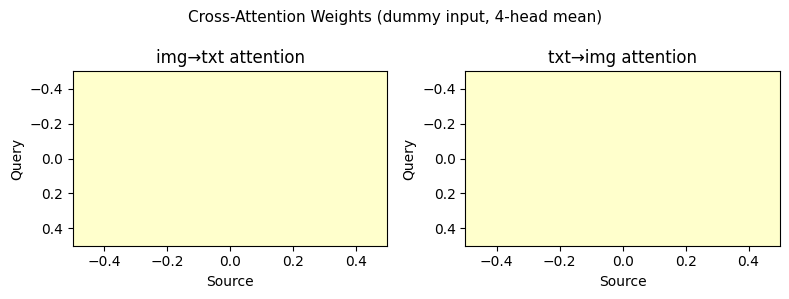

Architecture notebook complete. Proceed to notebook 08 (Training).


In [17]:
# ── Cross-attention weight visualization (on dummy input) ─────
# attn shape: (B, num_heads, tgt_seq, src_seq) = (1, 4, 1, 1)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, attn, title in [
    (axes[0], img_attn.cpu().squeeze(0).mean(0), "img→txt attention"),
    (axes[1], txt_attn.cpu().squeeze(0).mean(0), "txt→img attention"),
]:
    attn_2d = attn.numpy().reshape(1, -1) if attn.numpy().ndim < 2 else attn.numpy()
    ax.imshow(attn_2d, cmap="YlOrRd", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Source")
    ax.set_ylabel("Query")

plt.suptitle("Cross-Attention Weights (dummy input, 4-head mean)", fontsize=11)
plt.tight_layout()
plt.show()
print("Architecture notebook complete. Proceed to notebook 08 (Training).")